# ENGR 1451/2451 — Weekly Assignment 1
**10 points**

This assignment focuses on four goals: basic Python expressions, working with a `pandas` DataFrame, calculating summary statistics, and visualizing data.

**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested. Submit the completed notebook as directed in Canvas.

## What to hand in

Work this assignment with the **course tutor** in the class project. That is the AI help to use on this assignment, and it keeps the record for you — you do not write one yourself.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To pick up later, start a new chat in the same project, say which assignment you are on and which problem you stopped at, and keep going. That session gives you its own block, which you paste under the previous one.

Records are not graded for correctness or for how much help you needed, and extra credit is given for a record that shows you attempted the problem. The code and the written answers still have to be yours.

## LE1-1. Python warm-up (1 pt)
Use Python as a calculator. In one code cell, show an example of:
- addition,
- subtraction,
- multiplication,
- division, and
- exponentiation.

In [2]:
print("addition: 10+2=",10+2)
print("subtraction: 10-2=",10-2)
print("multiplication: 10*2=",10*2)
print("division: 10/2=",10/2)
print("exponentiation: 10^2=",10**2)

addition: 10+2= 12
subtraction: 10-2= 8
multiplication: 10*2= 20
division: 10/2= 5.0
exponentiation: 10^2= 100


## LE1-2. Iris data: structure, summary statistics, and visualization (6 pts)

A useful data-analysis workflow can be summarized as:
**question → data → cleaning → exploratory analysis → visualization → interpretation → communication → reproducible code**.

For this exercise, use the `iris.csv` file supplied with this assignment. Download it from Canvas and put it in a folder named `data` next to this notebook, so that the path `./data/iris.csv` works. The file contains measurements of sepal length/width and petal length/width for three iris species.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

iris = pd.read_csv("./data/iris.csv")
iris = iris.drop(columns=["rownames"], errors="ignore")
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### A. Understand the data (2 pts)
Using Python, answer:
1. How many observations (rows) are in the dataset?
2. Which variables are numerical? Are they continuous or discrete?
3. Which variable is categorical, and what are its categories?
4. How many observations belong to each species?

**Answer:**

In [4]:
# Useful tools: iris.shape, iris.dtypes, iris.select_dtypes(),
# iris["Species"].unique(), iris["Species"].value_counts()

rows = len(iris)
print("1. There are",rows, "observations.")

#print(iris.dtypes)
#print(iris.select_dtypes(include="number"))
print("2. The sepal and petal length and width variables are numerical. they are also continuous (measurements)")

#print(iris.select_dtypes(include="object"))
print("3. The species variable is categorical and the categories are:",iris["Species"].unique())

#print(iris["Species"].value_counts())
print("4. Each species has 50 observations.")


1. There are 150 observations.
2. The sepal and petal length and width variables are numerical. they are also continuous (measurements)
3. The species variable is categorical and the categories are: ['setosa' 'versicolor' 'virginica']
4. Each species has 50 observations.


### B. Analyze *versicolor* (2 pts)
1. Create a DataFrame containing only `versicolor` flowers.
2. Report the mean and median of each numerical variable.
3. Briefly explain why a single overall mean for all three species can be misleading.

**Answer:**

In [5]:
versicolor = iris.loc[
    iris["Species"] == "versicolor",
    :
]
#display(versicolor)
print("1.", versicolor.head())

print("2. Sepal Length mean:", versicolor["Sepal.Length"].mean())
print("Sepal Length median:", versicolor["Sepal.Length"].median())
print("Sepal Width mean:", versicolor["Sepal.Width"].mean())
print("Sepal Width median:", versicolor["Sepal.Width"].median())
print("Petal Length mean:", versicolor["Petal.Length"].mean())
print("Petal Length median:", versicolor["Petal.Length"].median())
print("Petal Width mean:", versicolor["Petal.Width"].mean())
print("Petal Width median:", versicolor["Petal.Width"].median())

print("3. Each species has it's own distribution of sepal/petal lengths and widths that come from 3 different populations. If you wanted to know the mean lengths and widths across all iris species, then a single overall mean would be appropriate, but on its own it would not accurately capture any of the 3 populations themselves.")


1.     Sepal.Length  Sepal.Width  Petal.Length  Petal.Width     Species
50           7.0          3.2           4.7          1.4  versicolor
51           6.4          3.2           4.5          1.5  versicolor
52           6.9          3.1           4.9          1.5  versicolor
53           5.5          2.3           4.0          1.3  versicolor
54           6.5          2.8           4.6          1.5  versicolor
2. Sepal Length mean: 5.936
Sepal Length median: 5.9
Sepal Width mean: 2.7700000000000005
Sepal Width median: 2.8
Petal Length mean: 4.26
Petal Length median: 4.35
Petal Width mean: 1.3259999999999998
Petal Width median: 1.3
3. Each species has it's own distribution of sepal/petal lengths and widths that come from 3 different populations. If you wanted to know the mean lengths and widths across all iris species, then a single overall mean would be appropriate, but on its own it would not accurately capture any of the 3 populations themselves.


### C. Visualize the iris data (2 pts)
Create a scatter plot of **Petal.Length** versus **Petal.Width** for all flowers in the iris dataset.

1. Put `Petal.Width` on the x-axis and `Petal.Length` on the y-axis.
2. Color the points by species so the three species can be compared.
3. Label both axes and include a legend.
4. Briefly describe the main pattern you see in the plot.

**Answer:**

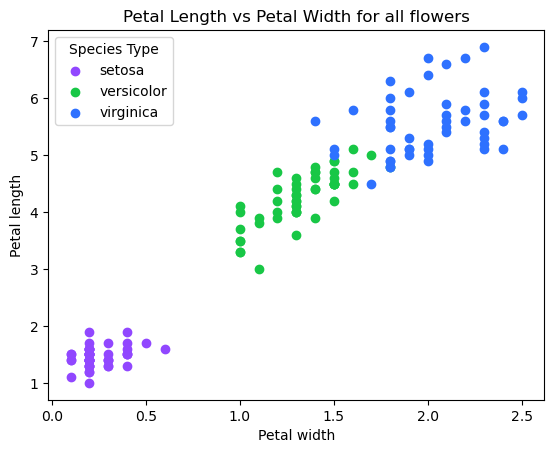

4. Petal Length and Petal Width correlate positively. Setosa has the smallest petal length + width, while versicolor is more in the middle of the range and virginica overall tends to have the longest/widest petals.


In [6]:
fig, ax = plt.subplots()

colors={"setosa" : "#9147FF","versicolor" : "#18C746","virginica" : "#2E71FF" }

for species, group in iris.groupby("Species"):
    ax.scatter(
        group["Petal.Width"],
        group["Petal.Length"],
        label=species, color=colors[species]
    )

ax.set_title("Petal Length vs Petal Width for all flowers")
ax.set_xlabel("Petal width")
ax.set_ylabel("Petal length")
ax.legend(title="Species Type")
plt.show()

print("4. Petal Length and Petal Width correlate positively. Setosa has the smallest petal length + width, while versicolor is more in the middle of the range and virginica overall tends to have the longest/widest petals.")

## LE1-3. Distribution shape and appropriate statistics (3 pts)

For each situation, state:
1. expected shape: **symmetric, right-skewed, or left-skewed**;
2. better measure of center: **mean or median**;
3. better measure of spread: **standard deviation or IQR**;
4. a brief reason.

Each case is worth 0.75 pt.

| Case | Situation |
|---|---|
| **a** | House prices: Q1 = \$350k, median = \$450k, Q3 = \$1.0M, with a meaningful number above \$6M |
| **b** | House prices: Q1 = \$300k, median = \$600k, Q3 = \$900k, with very few above \$1.2M |
| **c** | Weekly alcoholic drinks among students: most consume 0, while a few consume many |
| **d** | Scores on a straightforward 100-point quiz: most students score in the 80s and 90s, with a few much lower scores |

**Answers:**

**a. House prices: Q1 =  350𝑘,𝑚𝑒𝑑𝑖𝑎𝑛= 450k, Q3 =  1.0𝑀,𝑤𝑖𝑡ℎ𝑎𝑚𝑒𝑎𝑛𝑖𝑛𝑔𝑓𝑢𝑙𝑛𝑢𝑚𝑏𝑒𝑟𝑎𝑏𝑜𝑣𝑒 6M**
<br> 1. mean>median so expected shape is right-skewed
<br> 2. median
<br> 3. IQR
<br> 4. Because of the prescence of outliers (houses over 6M), the median and IQR better represent the center and spread of the data.
<br>**b. House prices: Q1 =  300𝑘,𝑚𝑒𝑑𝑖𝑎𝑛= 600k, Q3 =  900𝑘,𝑤𝑖𝑡ℎ𝑣𝑒𝑟𝑦𝑓𝑒𝑤𝑎𝑏𝑜𝑣𝑒 1.2M**
<br> 1. mean>median so expected shape is right-skewed
<br> 2. median
<br> 3. IQR
<br> 4. The 1.2M outliers would skew the mean + SD higher while the meadian + IQR would better represent the center and spread of the data.
<br>**c. 	Weekly alcoholic drinks among students: most consume 0, while a few consume many**
<br> 1. mean>median so expected shape is right-skewed
<br> 2. median
<br> 3. IQR
<br> 4. If most students consume 0 drinks a week, then the median + IQR will better represent the center and spread of the data without being skewed by the few who consume many.
<br>**d. Scores on a straightforward 100-point quiz: most students score in the 80s and 90s, with a few much lower scores**
<br> 1. mean < median so expected shape is left-skewed
<br> 2. median
<br> 3. IQR
<br> 4. The median and IQR better represent the center and spread of the scores because they are less affected by the much lower scores.

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.

Assignments are not graded for correctness or for how much help you needed, and extra credit is given for a record that shows you attempted the problem. They are read to find out which steps are hardest, and used to improve the course.

<!-- Paste your session record blocks in this cell, one after another. -->

{
  "schema_version": "engr-tutor-export-2",
  "assignment": "LE01",
  "export_n": 1,
  "session_date": "2026-09-04",
  "messages": [
    {"i": 1, "who": "student", "text": "for question A #2, it asks \"Which variables are numerical? Are they continuous or discrete?\" What exactly is meant by continuous or discrete here, is that just asking which are float vs integers?"},
    {"i": 2, "who": "tutor", "text": "Continuous vs discrete is about what the variable measures, not how Python stores it. Continuous: can take any value in a range (height, weight, time). Discrete: only specific separate values, usually counts (siblings, pets). dtype (float vs int) is a storage detail, not a measurement fact — a count stored as 2.0 is still discrete, a continuous measurement rounded to two decimals is still continuous. [trimmed]"},
    {"i": 3, "who": "student", "text": "The 4 float64 variables are all measurements, so that would be categorized as continuous right? and then theres 1 object type variable, so there are no discrete numerical variables"},
    {"i": 4, "who": "tutor", "text": "That's the right reasoning. The four float64 columns are all physical measurements, so continuous is correct for all four. And since the one non-numeric column (Species) is categorical, there are no discrete numerical variables — four continuous numerical variables and one categorical variable."},
    {"i": 5, "who": "student", "text": "what exactly does iris.select_dtypes() do?"},
    {"i": 6, "who": "tutor", "text": "select_dtypes() filters columns by data type and returns a smaller DataFrame with only matching columns. Takes include and/or exclude keyword args. Example on a made-up frame with name/age/gpa columns: df.select_dtypes(include=\"number\") returns just age and gpa. Common type strings: \"number\", \"float64\", \"int64\", \"object\". [trimmed]"},
    {"i": 7, "who": "student", "text": "can you explain why my code is returning an empty data frame with just a header? \"versicolor = iris.loc[\n    iris[\"Species\"] == \"Versicolor\",\n    :\n]\" this is for B1", "code": true},
    {"i": 8, "who": "tutor", "text": "Your loc/mask mechanics are right. The catch: == on strings is an exact match including capitalization. \"versicolor\" == \"Versicolor\" is False, so every row gets False and you get zero rows back. Check iris[\"Species\"].unique() to see the actual capitalization."},
    {"i": 9, "who": "student", "text": "oh you're right it should have been lower case versicolor, thank you. My next question is how can I change the group colors in this plot \"fig, ax = plt.subplots()\nfor species, group in iris.groupby(\"Species\"):\n    ax.scatter(\n        group[\"Petal.Width\"],\n        group[\"Petal.Length\"],\n        label=species,\n    )\nax.set_title(\"Petal Length vs Petal Width for all flowers\")\nax.set_xlabel(\"Petal width\")\nax.set_ylabel(\"Petal length\")\nax.legend(title=\"Species\")\nplt.show()\"", "code": true},
    {"i": 10, "who": "tutor", "text": "ax.scatter takes a color (or c) argument. Options: a dict keyed by group name (colors = {\"setosa\": \"tab:blue\", ...}, then color=colors[species] in the loop), or a list cycled by index. Any matplotlib named color or hex code works; without color specified matplotlib cycles its own default palette, which is what your current code does. [trimmed]"},
    {"i": 11, "who": "student", "text": "I defined the colors like this \"colors={\"setosa\" : \"9147FF\",\"versicolor\" : \"18C746\",\"virginica\" : \"2E71FF\" }\" but got this error \"'color' kwarg must be a color or sequence of color specs.  For a sequence of values to be color-mapped, use the 'c' argument instead.\"", "code": true},
    {"i": 12, "who": "tutor", "text": "Your hex codes are missing the # prefix — matplotlib only recognizes hex strings starting with #. Fix: colors = {\"setosa\": \"#9147FF\", \"versicolor\": \"#18C746\", \"virginica\": \"#2E71FF\"}. Everything else about how you're using the dictionary is fine."},
    {"i": 13, "who": "student", "text": "make my record"},
    {"i": 14, "who": "tutor", "text": "What date should I put on this session's record?"},
    {"i": 15, "who": "student", "text": "todays date, 9/4/2026"}
  ],
  "events": [
    {"i": 2, "part": "1-2A", "type": "explain"},
    {"i": 4, "part": "1-2A", "type": "part_pass"},
    {"i": 6, "part": "1-2A", "type": "explain"},
    {"i": 7, "part": "1-2B", "type": "code"},
    {"i": 9, "part": "1-2C", "type": "code"},
    {"i": 10, "part": "1-2C", "type": "explain"},
    {"i": 11, "part": "1-2C", "type": "code"}
  ],
  "parts": [
    {"part": "1-2A", "exchanges": 2, "max_tier": 1, "passed": true},
    {"part": "1-2B", "exchanges": 1, "max_tier": 3, "passed": false},
    {"part": "1-2C", "exchanges": 2, "max_tier": 3, "passed": false}
  ],
  "tutor_assessment": [
    "The longest stalls were mechanical debugging rather than conceptual: a capitalization mismatch in the B1 filter and a missing '#' prefix on hex color codes for the C scatter; both resolved in one exchange once the error text was in view.",
    "No 'I got it, let's move on' or release-valve pulls occurred this session, so no signal of tutor-side unhelpfulness to flag."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm every cell ran without errors.
2. Confirm your plot and printed values are visible in the saved file.
3. Confirm your session record blocks are pasted into the cell above.
4. Save the notebook, then upload the `.ipynb` to Canvas.

### Reference
Adapted from exercises in *OpenIntro Statistics*, 4th ed., and the original course assignment.